# scPhyTr tutorial — how gene expression evolves along a cell lineage

**scPhyTr** treats single-cell expression as a *quantitative trait evolving on a phylogeny*: a
latent Brownian-motion / Ornstein–Uhlenbeck process at every node of the lineage tree, observed
at the leaves through an explicit **count** model. It has a **scanpy-like API** — `pp` (setup),
`tl` (tools), `pl` (plots) — over a modular backend, and the cells of each leaf are kept as
**subclonal replicates** (never collapsed to pseudobulk).

Dataset: the B2905 melanoma model of
[Hirsch et al. 2025, *Cell Systems*](https://doi.org/10.1016/j.cels.2025.101156) — 23 clonal
sublines with a reconstructed consensus phylogeny and per-cell Smart-seq2 RNA-seq.

We cover, all through `ph.tl` / `ph.pl`:
1. **Heritability** — Pagel's $\lambda$
2. **Selection** — BM vs OU vs adaptive OU, on the count model
3. **Plasticity** — heritable vs within-clone variance (the replicates at work)
4. **Rate shifts** — de-novo clade-specific rates, with `pl.rate_tree`
5. **Co-evolution** — the deconfounded gene–gene matrix $K$, with `pl.matrix`
6. **Modules** — phylogenetic factor analysis, with `pl.loadings`

## 0. Setup — build an AnnData and attach the lineage tree

In [1]:
import os, sys
root = os.getcwd()
while root != "/" and not os.path.isdir(os.path.join(root, "src", "scphytr")):
    root = os.path.dirname(root)
sys.path[:0] = [root, os.path.join(root, "src")]
os.chdir(root)

import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import scphytr as ph
from analysis.melanoma.load import load_tree, load_counts, load_regimes

# per-cell raw counts + the subline each cell belongs to
X, genes, clone, _ = load_counts()
adata = ad.AnnData(X=X.astype(float))
adata.var_names = [str(g).split("_")[-1] for g in genes]   # gene symbols
adata.var_names_make_unique()
adata.obs["species"] = clone                                # cell -> leaf (subline) label
tree = load_tree()

ph.pp.setup_anndata(adata, tree)        # attach tree + per-cell leaf index + size factors
print(adata)
print("\nsublines:", ", ".join(tree.phylotree.get_leaf_names()))

AnnData object with n_obs × n_vars = 169 × 55401
    obs: 'species', '_leaf_index', 'size_factors'
    uns: 'tree', '_species_obs', '_size_factor_obs'

sublines: C23, C17, C12, C10, C3, C14, C5, C9, C24, C6, C21, C19, C1, C22, C4, C13, C18, C15, C11, C16, C8, C20, C7


## 1. Heritability — `tl.heritability` (Pagel's $\lambda$)

How much of a gene's variation follows the lineage (**heritable**, $\lambda\to1$) versus being
reshuffled at every division (**plastic**, $\lambda\to0$)? We contrast proliferation against
invasion/EMT genes, then look at the genome-wide spectrum.

In [2]:
panel = ["Mki67", "Mcm5", "Actb", "Gapdh", "Adamts1", "Fn1", "Vim"]
ph.tl.heritability(adata, genes=panel)
print(adata.var.loc[panel, ["lambda", "lambda_p"]].round(3).to_string())

         lambda  lambda_p
Mki67     0.789     0.034
Mcm5      0.578     0.017
Actb      0.000     0.500
Gapdh     0.311     0.247
Adamts1   0.236     0.279
Fn1       0.000     0.500
Vim       0.000     0.500


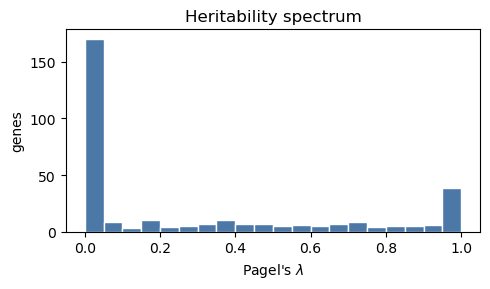

In [3]:
ph.tl.heritability(adata, genes=list(adata.var_names[:400]))   # spectrum over many genes
lam = adata.var["lambda"].dropna()
plt.figure(figsize=(5, 3))
plt.hist(lam, bins=20, color="#4c78a8", edgecolor="white")
plt.xlabel("Pagel's $\\lambda$"); plt.ylabel("genes"); plt.title("Heritability spectrum")
plt.tight_layout(); plt.show()

Proliferation genes (*Mki67*, *Mcm5*) are heritable; invasion/EMT genes (*Fn1*, *Vim*) sit near
$\lambda=0$. *(λ is a leaf-level statistic — the replicate-aware view of heritability is the
count-model $V_\text{herit}$ in §3.)*

## 2. Selection — `tl.detect_adaptive` (BM vs OU vs adaptive OU2, on the counts)

Is a gene drifting (**BM**), pulled to an optimum (**OU**), or shifted to a *different* optimum
in a chosen subline group (**two-regime OU** = adaptive)? Fit all three to the **per-cell
counts** (cells as subclonal replicates) and select by AIC.

In [4]:
regimes, n_reg = load_regimes(tree, "har")     # the paper's chosen-vs-background painting
ph.tl.detect_adaptive(adata, genes=panel, regimes=regimes, n_regimes=n_reg)
print(adata.var.loc[panel, ["adaptive_model", "adaptive"]].to_string())

        adaptive_model  adaptive
Mki67              OU2       1.0
Mcm5               OU2       1.0
Actb                OU       1.0
Gapdh              OU2       1.0
Adamts1             OU       1.0
Fn1                 OU       1.0
Vim                OU2       1.0


## 3. Plasticity — `tl.plasticity` (this is where the replicates matter)

The 5–8 cells per subline are kept as repeated observations, so their **spread** is the
**plastic** (within-clone) variance, separate from the **heritable** variance between sublines.

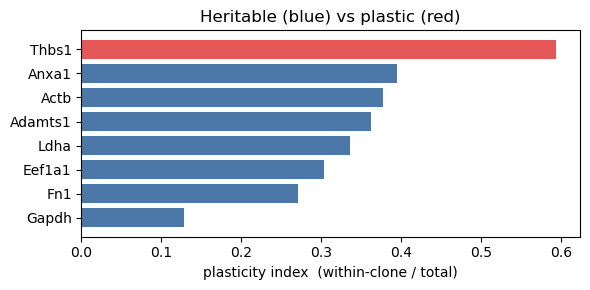

         plasticity  v_herit  v_plast
Gapdh          0.13     0.65     0.10
Fn1            0.27     1.56     0.58
Eef1a1         0.30     0.22     0.10
Ldha           0.34     0.37     0.19
Adamts1        0.36     1.52     0.86
Actb           0.38     0.25     0.15
Anxa1          0.39     0.44     0.29
Thbs1          0.59     0.76     1.11


In [5]:
plast_panel = ["Thbs1", "Fn1", "Adamts1", "Anxa1", "Gapdh", "Actb", "Eef1a1", "Ldha"]
ph.tl.plasticity(adata, genes=plast_panel)
frac = adata.var.loc[plast_panel, "plasticity"].sort_values()
plt.figure(figsize=(6, 3))
plt.barh(range(len(frac)), frac.values,
         color=["#e45756" if v > 0.4 else "#4c78a8" for v in frac.values])
plt.yticks(range(len(frac)), frac.index)
plt.xlabel("plasticity index  (within-clone / total)"); plt.title("Heritable (blue) vs plastic (red)")
plt.tight_layout(); plt.show()
print(adata.var.loc[frac.index, ["plasticity", "v_herit", "v_plast"]].round(2).to_string())

Invasion/ECM genes (*Thbs1*, *Fn1*) are the most plastic; housekeeping genes are heritable —
visible **only because** the per-cell replicates are kept rather than averaged into a pseudobulk.

## 4. Rate shifts — `tl.detect_rate_shifts` + `pl.rate_tree`

Does the *rate* of evolution accelerate in a subclade? `detect_rate_shifts` finds shifts de novo
(calibrated greedy search), and `pl.rate_tree` draws the tree with clades coloured by rate. With
only 23 sublines real power is limited, so we add an illustrative character with a planted shift.

detected 1 rate shift(s); rates [0.17, 7.78]


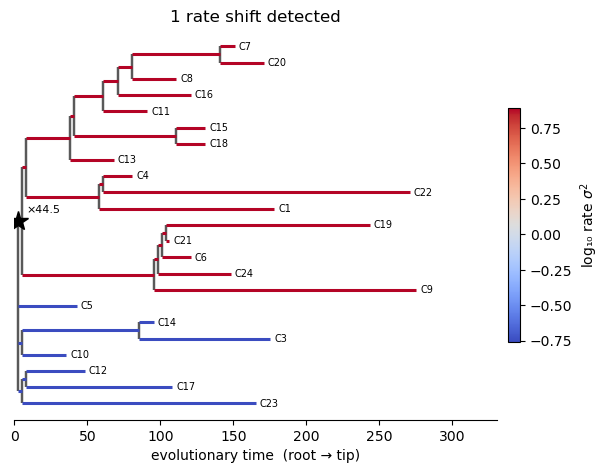

In [6]:
from scphytr.utils.pruning import paint_regimes
# plant an 8x rate shift in a clade, as a per-cell character on the AnnData
leaves = tree.phylotree.get_leaf_names()
internals = [nd for nd in tree.root.traverse()
             if not nd.is_leaf() and not nd.is_root()
             and 5 <= len(nd.get_leaves()) <= len(leaves) - 5]
clade = max(internals, key=lambda c: len(c.get_leaves()))
reg, _ = paint_regimes(tree, [clade]); rates = {0: 0.5, 1: 8.0}
rng = np.random.default_rng(0); leaf_val = {}
def desc(nd, pv):
    v = (pv + rng.normal(0, np.sqrt(rates[reg[nd]] * nd.dist))) if nd is not tree.root else 0.0
    if nd.is_leaf(): leaf_val[nd.name] = v
    for c in nd.children: desc(c, v)
desc(tree.root, 0.0)
adata.obs["fast_clade_demo"] = [leaf_val[s] for s in adata.obs["species"]]

res = ph.tl.detect_rate_shifts(adata, character="fast_clade_demo", max_shifts=3)
print(f"detected {len(res['shifts'])} rate shift(s); "
      f"rates {[round(r,2) for r in res['fit'].params['rates']]}")
ph.pl.rate_tree(adata); plt.show()

## 5. Co-evolution — `tl.evolutionary_correlation` + `pl.matrix`

The off-diagonal of the rate matrix $K$ is which genes co-evolve — fit straight from the cells
(count model), deconfounding shared ancestry, never collapsing to pseudobulk.

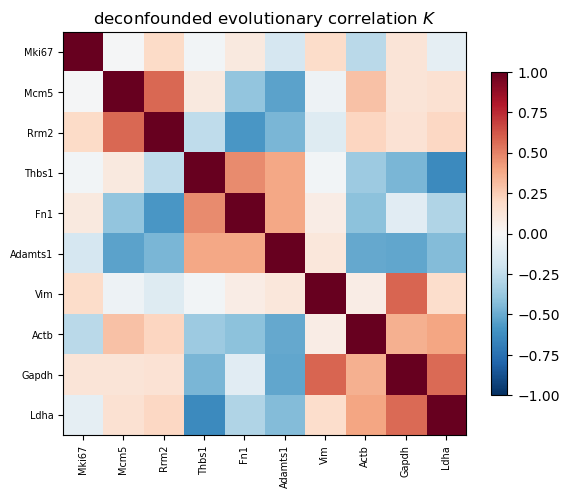

In [7]:
co = ["Mki67", "Mcm5", "Rrm2", "Thbs1", "Fn1", "Adamts1", "Vim", "Actb", "Gapdh", "Ldha"]
ph.tl.evolutionary_correlation(adata, genes=co)
ph.pl.matrix(adata, "K_corr", title="deconfounded evolutionary correlation $K$"); plt.show()

## 6. Modules — `tl.factor_analysis` + `pl.loadings`

Factorize $K = WW^\top$ with a few latent programs that evolve on the tree; the loadings $W$
are the gene programs.

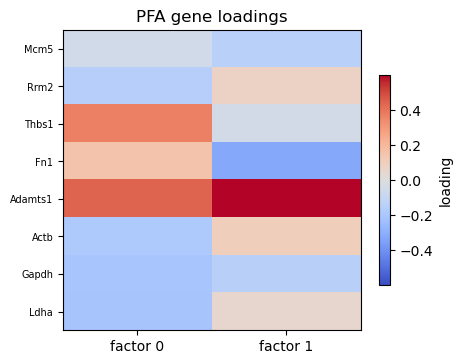

In [8]:
ph.tl.factor_analysis(adata, k=2, genes=co)
ph.pl.loadings(adata, top=6); plt.show()

## Bonus — `pl.plot_tree(adata, color=gene)`

Any gene (or obs column) can be drawn on the tree.

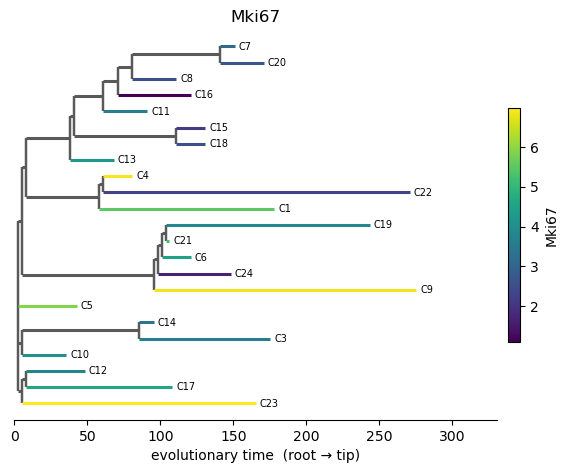

In [9]:
ph.pl.plot_tree(adata, color="Mki67"); plt.show()

## Wrap-up

From one model and a scanpy-like API we read out **heritability** (`tl.heritability`),
**selection** (`tl.detect_adaptive`), **plasticity** (`tl.plasticity`), **rate shifts**
(`tl.detect_rate_shifts` → `pl.rate_tree`), **co-evolution** (`tl.evolutionary_correlation` →
`pl.matrix`) and **modules** (`tl.factor_analysis` → `pl.loadings`) — the read-outs PATH,
EvoGeneX/CAGEE, Hotspot and RevBayes provide separately, all on the per-cell counts without
collapsing to pseudobulk.

**Next:** method & math in [`docs/01_methods.md`](../docs/01_methods.md); benchmarks vs
PATH / Hotspot / RevBayes / EvoGeneX in [`analysis/benchmark/`](../analysis/benchmark).